In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("Bank Marketing Dataset.csv")

In [4]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

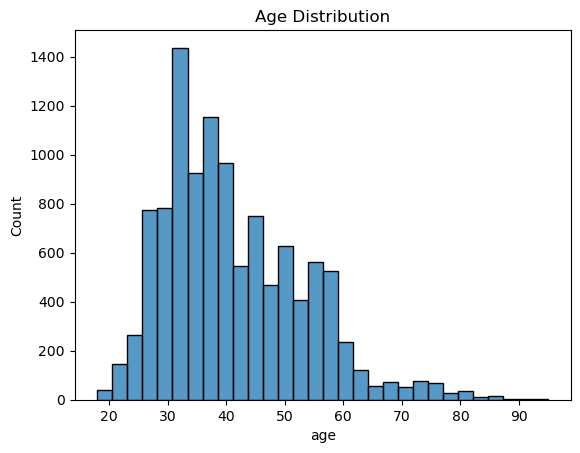

In [5]:
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.show()

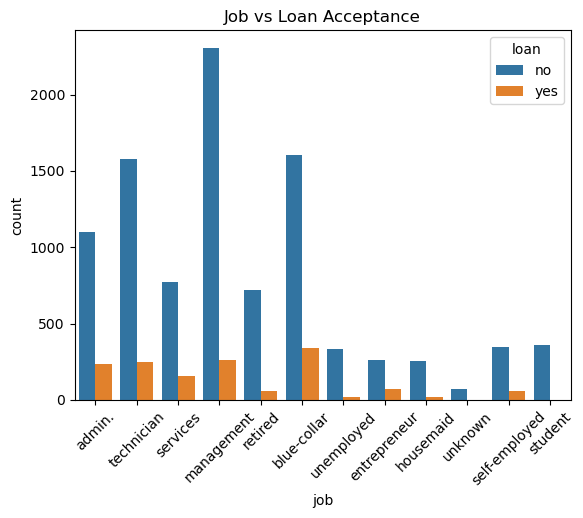

In [6]:
sns.countplot(x='job', hue='loan', data=df)
plt.xticks(rotation=45)
plt.title("Job vs Loan Acceptance")
plt.show()

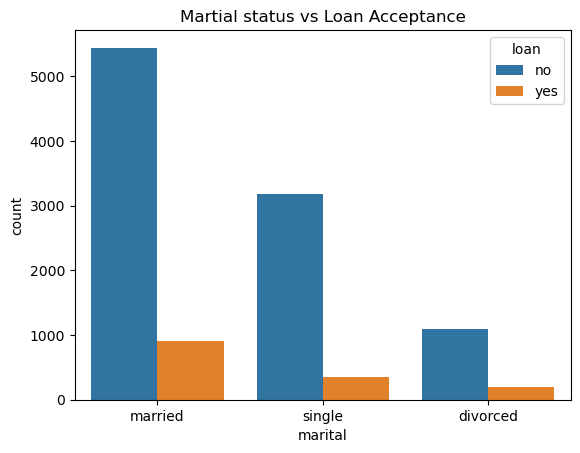

In [7]:
sns.countplot(x='marital', hue='loan', data=df)
plt.title("Martial status vs Loan Acceptance")
plt.show()

In [8]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [9]:
x = df.drop('loan', axis=1)
y = df['loan']

In [10]:
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size=0.3, random_state=42)

In [15]:
lr = LogisticRegression(max_iter=2000, solver='liblinear')
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

In [17]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

In [18]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8748880262765004
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      2932
           1       0.33      0.00      0.01       417

    accuracy                           0.87      3349
   macro avg       0.60      0.50      0.47      3349
weighted avg       0.81      0.87      0.82      3349



In [20]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.792773962376829
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2932
           1       0.22      0.26      0.24       417

    accuracy                           0.79      3349
   macro avg       0.55      0.56      0.56      3349
weighted avg       0.81      0.79      0.80      3349



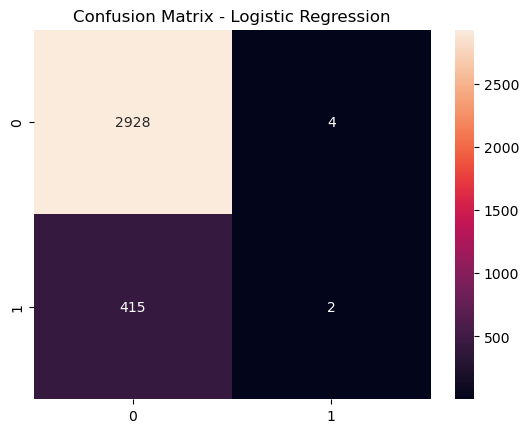

In [21]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()